## Data Loading

In [3]:
import pandas as pd

df = pd.read_csv("../data/Hospital_Dataset Updated.csv")
df.head()

,date,hospital_branch,weekday,total_beds,icu_beds,occupied_beds,occupied_icu_beds,available_beds,admissions,discharges,emergency_cases,staff_available
0,1/1/2018,Metro Hospital,Wednesday,175,31,140,25,35,40,38,18,92
1,1/2/2018,Metro Hospital,Thursday,175,31,175,21,0,69,19,26,57
2,1/3/2018,Metro Hospital,Friday,175,31,172,22,3,31,34,22,113
3,1/4/2018,Metro Hospital,Saturday,175,31,175,27,0,52,15,12,106
4,1/5/2018,Metro Hospital,Sunday,175,31,175,30,0,69,19,24,59


## Data Cleaning

- No missing values found in dataset
- No duplicate records detected
- Date column converted to datetime format
- Data sorted chronologically for time-series analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               3000 non-null   str  
 1   hospital_branch    3000 non-null   str  
 2   weekday            3000 non-null   str  
 3   total_beds         3000 non-null   int64
 4   icu_beds           3000 non-null   int64
 5   occupied_beds      3000 non-null   int64
 6   occupied_icu_beds  3000 non-null   int64
 7   available_beds     3000 non-null   int64
 8   admissions         3000 non-null   int64
 9   discharges         3000 non-null   int64
 10  emergency_cases    3000 non-null   int64
 11  staff_available    3000 non-null   int64
dtypes: int64(9), str(3)
memory usage: 281.4 KB


In [5]:
df.isnull().sum()

date                 0
hospital_branch      0
weekday              0
total_beds           0
icu_beds             0
occupied_beds        0
occupied_icu_beds    0
available_beds       0
admissions           0
discharges           0
emergency_cases      0
staff_available      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df = df.sort_values(by='date')

## Occupancy Flow Understanding
Occupancy depends on patient flow:
- Admissions increase bed occupancy
- Discharges decrease bed occupancy
- Emergency cases have minor effect
- Strong dependency on previous day occupancy → time-series behavior

In [10]:
df[['occupied_beds','admissions','discharges','emergency_cases']].corr()

,occupied_beds,admissions,discharges,emergency_cases
occupied_beds,1.000000,0.200523,-0.132904,-0.045524
admissions,0.200523,1.000000,-0.044854,-0.045925
discharges,-0.132904,-0.044854,1.000000,-0.039984
emergency_cases,-0.045524,-0.045925,-0.039984,1.000000


In [11]:
df[['occupied_beds','admissions','discharges']].head()

,occupied_beds,admissions,discharges
0,140,40,38
1,175,69,19
2,172,31,34
3,175,52,15
4,175,69,19


## ICU Validation

- ICU utilization calculated as occupied_icu_beds / icu_beds
- All values are within range (0–1)
- Confirms ICU capacity is not exceeded
- Dataset is consistent and reliable for modeling

In [12]:
df['icu_utilization_check'] = df['occupied_icu_beds'] / df['icu_beds']
df[['occupied_icu_beds','icu_beds','icu_utilization_check']].head()

,occupied_icu_beds,icu_beds,icu_utilization_check
0,25,31,0.806452
1,21,31,0.677419
2,22,31,0.709677
3,27,31,0.870968
4,30,31,0.967742


## Feature Engineering

- Lag features (lag_1, lag_2) capture previous occupancy trends
- Rolling mean (3-day) smooths short-term fluctuations
- Occupancy rate represents hospital load
- ICU utilization captures ICU pressure
- These features improve forecasting performance

In [13]:
df['lag_1'] = df['occupied_beds'].shift(1)
df['lag_2'] = df['occupied_beds'].shift(2)

In [14]:
df['rolling_mean_3'] = df['occupied_beds'].rolling(3).mean()

In [15]:
df['occupancy_rate'] = df['occupied_beds'] / df['total_beds']
df['icu_utilization'] = df['occupied_icu_beds'] / df['icu_beds']

## Encoding

- hospital_branch converted into numerical format using one-hot encoding
- weekday also converted into numerical format
- drop_first=True used to avoid multicollinearity
- Required for machine learning models

In [16]:
df = pd.get_dummies(df, columns=['hospital_branch'], drop_first=True)

In [17]:
df = pd.get_dummies(df, columns=['weekday'], drop_first=True)

In [18]:
df.head()

,date,total_beds,icu_beds,occupied_beds,occupied_icu_beds,available_beds,admissions,discharges,emergency_cases,staff_available,...,lag_2,rolling_mean_3,occupancy_rate,icu_utilization,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday
0,2018-01-01,175,31,140,25,35,40,38,18,92,...,NaN,NaN,0.800000,0.806452,False,False,False,False,False,True
1,2018-01-02,175,31,175,21,0,69,19,26,57,...,NaN,NaN,1.000000,0.677419,False,False,False,True,False,False
2,2018-01-03,175,31,172,22,3,31,34,22,113,...,140.0,162.333333,0.982857,0.709677,False,False,False,False,False,False
3,2018-01-04,175,31,175,27,0,52,15,12,106,...,175.0,174.000000,1.000000,0.870968,False,True,False,False,False,False
4,2018-01-05,175,31,175,30,0,69,19,24,59,...,172.0,174.000000,1.000000,0.967742,False,False,True,False,False,False


## Target Variable

- Target created using next-day occupancy
- shift(-1) aligns future values
- Enables time-series forecasting

In [19]:
df['target'] = df['occupied_beds'].shift(-1)

In [20]:
df.dropna(inplace=True)

In [21]:
df[['occupied_beds','target']].head()

,occupied_beds,target
2,172,175.0
3,175,175.0
4,175,175.0
5,175,172.0
6,172,174.0


## EDA

- Occupancy trend shows variation over time
- Correlation analysis shows weak direct relationships
- Indicates importance of time-based features (lag variables)

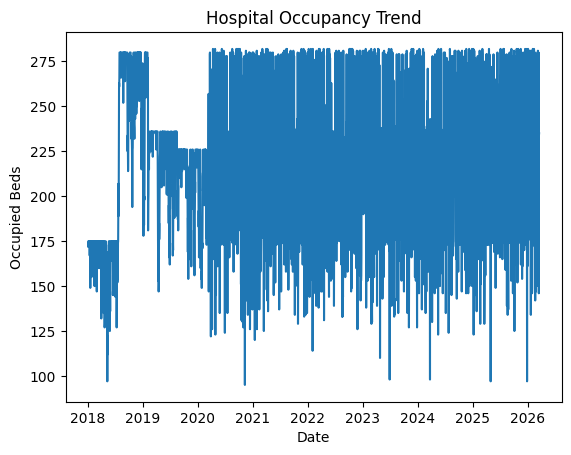

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Occupancy Trend
plt.figure()
plt.plot(df['date'], df['occupied_beds'])
plt.title("Hospital Occupancy Trend")
plt.xlabel("Date")
plt.ylabel("Occupied Beds")
plt.show()

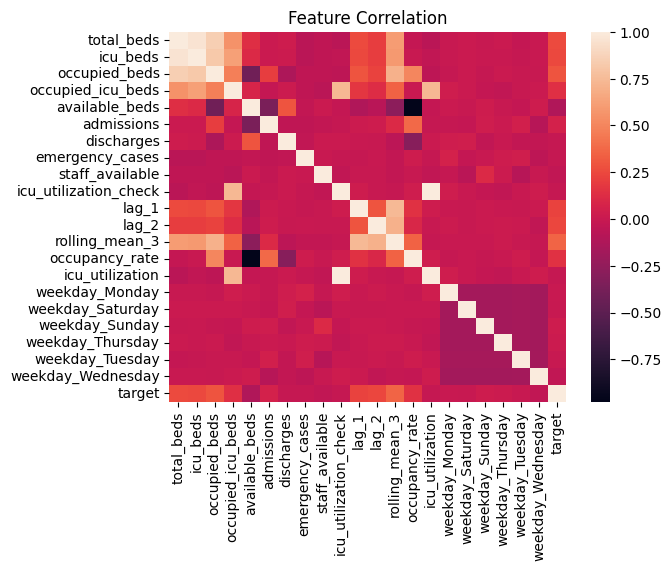

In [23]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True))
plt.title("Feature Correlation")
plt.show()

## Baseline Model

- Linear Regression used as baseline model
- Time-based split applied (no shuffle)
- Model predicts next-day occupancy
- Evaluated using MAE and R2 score

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(['target','date'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 35.55960147142361
R2 Score: -0.06946407223128248


## Model Evaluation

- MAE ≈ 35 indicates average prediction error
- R2 score is negative, indicating poor model fit
- Linear Regression is too simple for complex time-series data
- Model serves as baseline for further improvement
- Future work can include advanced models like Random Forest or XGBoost

In [29]:
df.to_csv("../outputs/final_cleaned_data.csv", index=False)